# Workshop Prático: Técnicas de Otimização em SBSE

**Objetivo:** Implementar e comparar algoritmos de otimização para resolver o problema de decomposição automática de arquitetura de microsserviços.

**Problema:** Dado um conjunto de classes Java com suas dependências, encontrar a melhor decomposição em microsserviços que maximize coesão interna e minimize acoplamento entre serviços.

---
# Configuração do Ambiente

In [14]:
# Instalação de dependências
!pip install numpy matplotlib seaborn networkx pandas plotly -q


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
# Configurações para usar CPU e silenciar logs
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''
import warnings
warnings.filterwarnings('ignore')

# Imports principais
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd
import random
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
from abc import ABC, abstractmethod
import copy
import math
from collections import defaultdict

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
random.seed(42)
np.random.seed(42)

print("✅ Ambiente configurado com sucesso!")
print("🔧 Usando CPU apenas")
print("📚 Bibliotecas carregadas")

✅ Ambiente configurado com sucesso!
🔧 Usando CPU apenas
📚 Bibliotecas carregadas


## Parte 1: Representação do Problema e Função de Fitness

Primeiro, vamos implementar a representação do problema de decomposição de microsserviços e criar uma função de fitness robusta.

In [4]:
# @title Classe de Representação da Arquitetura de Microsserviços

@dataclass
class JavaClass:
    """Representa uma classe Java com suas características.
    
    Parameters:
        name (str): Nome da classe
        complexity (int): Complexidade da classe (linhas de código)
        dependencies (List[str]): Lista de classes que esta classe depende
    """
    name: str
    complexity: int
    dependencies: List[str]

class MicroserviceArchitecture:
    """Representa uma arquitetura de microsserviços como solução de otimização.
    
    A representação usa assignment vector: cada gene representa o serviço 
    atribuído à classe na posição correspondente.
    """
    
    def __init__(self, classes: List[JavaClass], max_services: int = 5):
        """
        Parameters:
            classes: Lista de classes Java do sistema
            max_services: Número máximo de microsserviços permitidos
        """
        self.classes = classes
        self.max_services = max_services
        self.n_classes = len(classes)
        
        # Cromossomo: assignment[i] = serviço da classe i
        self.assignment = np.random.randint(0, max_services, size=self.n_classes)
        
        # Matriz de dependências para cálculos eficientes
        self.dependency_matrix = self._build_dependency_matrix()
        
        # Cache para fitness (evita recálculos desnecessários)
        self._fitness_cache = None
        self._fitness_components_cache = None
    
    def _build_dependency_matrix(self) -> np.ndarray:
        """Constrói matriz de dependências entre classes.
        
        Returns:
            Matrix onde element[i][j] = 1 se classe i depende da classe j
        """
        matrix = np.zeros((self.n_classes, self.n_classes))
        class_to_index = {cls.name: i for i, cls in enumerate(self.classes)}
        
        for i, cls in enumerate(self.classes):
            for dep_name in cls.dependencies:
                if dep_name in class_to_index:
                    j = class_to_index[dep_name]
                    matrix[i][j] = 1
        
        return matrix
    
    def get_services_assignment(self) -> Dict[int, List[int]]:
        """Retorna mapeamento serviço -> lista de índices de classes.
        
        Returns:
            Dicionário onde chave = ID do serviço, valor = lista de classes
        """
        services = defaultdict(list)
        for class_idx, service_id in enumerate(self.assignment):
            services[service_id].append(class_idx)
        return dict(services)
    
    def calculate_cohesion(self) -> float:
        """Calcula coesão média dos microsserviços.
        
        Coesão = proporção de dependências internas ao serviço.
        
        Returns:
            Valor de coesão normalizado entre 0 e 1
        """
        services = self.get_services_assignment()
        total_cohesion = 0.0
        active_services = 0
        
        for service_classes in services.values():
            if len(service_classes) <= 1:
                continue  # Serviços com 1 classe têm coesão máxima por definição
                
            active_services += 1
            internal_deps = 0
            total_possible_deps = 0
            
            # Contar dependências internas vs possíveis
            for i in service_classes:
                for j in service_classes:
                    if i != j:
                        total_possible_deps += 1
                        if self.dependency_matrix[i][j] == 1:
                            internal_deps += 1
            
            # Coesão do serviço = deps internas / deps possíveis
            if total_possible_deps > 0:
                service_cohesion = internal_deps / total_possible_deps
            else:
                service_cohesion = 1.0  # Serviço sem dependências
                
            total_cohesion += service_cohesion
        
        return total_cohesion / max(active_services, 1)
    
    def calculate_coupling(self) -> float:
        """Calcula acoplamento entre microsserviços.
        
        Acoplamento = proporção de dependências externas (entre serviços).
        
        Returns:
            Valor de acoplamento normalizado entre 0 e 1 (menor é melhor)
        """
        external_deps = 0
        total_deps = 0
        
        for i in range(self.n_classes):
            for j in range(self.n_classes):
                if self.dependency_matrix[i][j] == 1:
                    total_deps += 1
                    # Dependência externa = classes em serviços diferentes
                    if self.assignment[i] != self.assignment[j]:
                        external_deps += 1
        
        if total_deps == 0:
            return 0.0  # Sistema sem dependências
        
        return external_deps / total_deps
    
    def calculate_load_balance(self) -> float:
        """Calcula balanceamento de carga entre serviços.
        
        Load balance = 1 - desvio padrão do tamanho dos serviços.
        
        Returns:
            Valor de balanceamento entre 0 e 1 (1 = perfeitamente balanceado)
        """
        services = self.get_services_assignment()
        
        # Calcular complexidade total por serviço
        service_complexities = []
        for service_classes in services.values():
            complexity = sum(self.classes[i].complexity for i in service_classes)
            service_complexities.append(complexity)
        
        if len(service_complexities) <= 1:
            return 1.0  # Um serviço = perfeitamente balanceado
        
        # Normalizar pelo desvio padrão
        mean_complexity = np.mean(service_complexities)
        std_complexity = np.std(service_complexities)
        
        if mean_complexity == 0:
            return 1.0
        
        # Balance score: quanto menor o desvio relativo, melhor o balance
        relative_std = std_complexity / mean_complexity
        balance_score = 1.0 / (1.0 + relative_std)
        
        return balance_score
    
    def calculate_fitness(self) -> Tuple[float, Dict[str, float]]:
        """Calcula fitness multi-objetivo da arquitetura.
        
        Returns:
            Tuple (fitness_total, componentes_detalhados)
        """
        # Usar cache se disponível
        if self._fitness_cache is not None:
            return self._fitness_cache, self._fitness_components_cache
        
        # Calcular componentes do fitness
        cohesion = self.calculate_cohesion()
        coupling = self.calculate_coupling()
        load_balance = self.calculate_load_balance()
        
        # Penalizar soluções com serviços vazios
        services = self.get_services_assignment()
        empty_services = self.max_services - len(services)
        empty_penalty = empty_services * 0.1
        
        # Função objetivo composta (maximizar coesão e balance, minimizar coupling)
        fitness = (
            0.4 * cohesion +           # 40% peso para coesão
            0.4 * (1.0 - coupling) +   # 40% peso para baixo acoplamento
            0.2 * load_balance -       # 20% peso para balanceamento
            empty_penalty              # Penalidade por serviços não utilizados
        )
        
        components = {
            'cohesion': cohesion,
            'coupling': coupling,
            'load_balance': load_balance,
            'empty_penalty': empty_penalty,
            'active_services': len(services)
        }
        
        # Cache dos resultados
        self._fitness_cache = fitness
        self._fitness_components_cache = components
        
        return fitness, components
    
    def invalidate_cache(self):
        """Invalida cache de fitness após modificações."""
        self._fitness_cache = None
        self._fitness_components_cache = None
    
    def copy(self) -> 'MicroserviceArchitecture':
        """Cria cópia profunda da arquitetura.
        
        Returns:
            Nova instância com mesmo estado
        """
        new_arch = MicroserviceArchitecture(self.classes, self.max_services)
        new_arch.assignment = self.assignment.copy()
        return new_arch

print("✅ Classe MicroserviceArchitecture implementada")
print("📊 Métricas disponíveis: coesão, acoplamento, balanceamento de carga")
print("🔄 Sistema de cache implementado para eficiência")

✅ Classe MicroserviceArchitecture implementada
📊 Métricas disponíveis: coesão, acoplamento, balanceamento de carga
🔄 Sistema de cache implementado para eficiência


In [5]:
# @title Criação do Dataset de Exemplo

def create_example_system() -> List[JavaClass]:
    """Cria um sistema exemplo para teste dos algoritmos.
    
    O sistema simula uma aplicação e-commerce com diferentes módulos
    que possuem dependências naturais entre si.
    
    Returns:
        Lista de classes Java com dependências realistas
    """
    
    # Definir classes do sistema e-commerce
    classes_data = [
        # Módulo de Usuários
        ('User', 50, []),
        ('UserRepository', 80, ['User']),
        ('UserService', 120, ['User', 'UserRepository']),
        ('UserController', 60, ['User', 'UserService']),
        
        # Módulo de Produtos
        ('Product', 70, []),
        ('ProductRepository', 90, ['Product']),
        ('ProductService', 150, ['Product', 'ProductRepository']),
        ('ProductController', 80, ['Product', 'ProductService']),
        
        # Módulo de Pedidos (depende de User e Product)
        ('Order', 100, ['User', 'Product']),
        ('OrderItem', 40, ['Product', 'Order']),
        ('OrderRepository', 110, ['Order', 'OrderItem']),
        ('OrderService', 200, ['Order', 'OrderItem', 'OrderRepository', 'UserService', 'ProductService']),
        ('OrderController', 90, ['Order', 'OrderService']),
        
        # Módulo de Pagamento
        ('Payment', 80, ['Order']),
        ('PaymentProcessor', 150, ['Payment', 'Order']),
        ('PaymentService', 130, ['Payment', 'PaymentProcessor']),
        
        # Módulo de Notificações (depende de todos)
        ('Notification', 60, []),
        ('EmailService', 100, ['Notification', 'User']),
        ('NotificationService', 120, ['Notification', 'EmailService', 'OrderService']),
        
        # Utilitários comuns
        ('DateUtils', 30, []),
        ('ValidationUtils', 45, []),
    ]
    
    # Converter para objetos JavaClass
    classes = []
    for name, complexity, deps in classes_data:
        classes.append(JavaClass(name=name, complexity=complexity, dependencies=deps))
    
    return classes

# Criar dataset e instância de teste
java_classes = create_example_system()
test_architecture = MicroserviceArchitecture(java_classes, max_services=5)

# Mostrar informações do sistema
print(f"📦 Sistema criado com {len(java_classes)} classes")
print(f"🔧 Máximo de {test_architecture.max_services} microsserviços")
print(f"🔗 Total de dependências: {np.sum(test_architecture.dependency_matrix)}")

# Testar função de fitness
fitness, components = test_architecture.calculate_fitness()
print(f"\n📊 Teste da função de fitness:")
print(f"   Fitness total: {fitness:.4f}")
for metric, value in components.items():
    print(f"   {metric}: {value:.4f}")

# Mostrar assignment inicial aleatório
print(f"\n🎲 Assignment inicial: {test_architecture.assignment}")
services = test_architecture.get_services_assignment()
for service_id, class_indices in services.items():
    class_names = [java_classes[i].name for i in class_indices]
    print(f"   Serviço {service_id}: {class_names}")

📦 Sistema criado com 21 classes
🔧 Máximo de 5 microsserviços
🔗 Total de dependências: 33.0

📊 Teste da função de fitness:
   Fitness total: 0.2437
   cohesion: 0.0792
   coupling: 0.8182
   load_balance: 0.6965
   empty_penalty: 0.0000
   active_services: 5.0000

🎲 Assignment inicial: [3 4 2 4 4 1 2 2 2 4 3 2 4 1 3 1 3 4 0 3 1]
   Serviço 3: ['User', 'OrderRepository', 'PaymentProcessor', 'Notification', 'DateUtils']
   Serviço 4: ['UserRepository', 'UserController', 'Product', 'OrderItem', 'OrderController', 'EmailService']
   Serviço 2: ['UserService', 'ProductService', 'ProductController', 'Order', 'OrderService']
   Serviço 1: ['ProductRepository', 'Payment', 'PaymentService', 'ValidationUtils']
   Serviço 0: ['NotificationService']


## Parte 2: Implementação dos Algoritmos de Otimização

Agora vamos implementar os três algoritmos principais: Genetic Algorithm, Simulated Annealing e Hill Climbing.

In [6]:
# @title Interface Base para Algoritmos de Otimização

class OptimizationAlgorithm(ABC):
    """Classe base para algoritmos de otimização.
    
    Define interface comum e funcionalidades compartilhadas.
    """
    
    def __init__(self, classes: List[JavaClass], max_services: int = 5):
        """Inicializa algoritmo base.
        
        Parameters:
            classes: Lista de classes Java do sistema
            max_services: Número máximo de microsserviços
        """
        self.classes = classes
        self.max_services = max_services
        
        # Histórico de execução
        self.fitness_history: List[float] = []
        self.best_solution: Optional[MicroserviceArchitecture] = None
        self.best_fitness: float = -np.inf
        
        # Estatísticas de performance
        self.evaluations_count: int = 0
        self.generations_count: int = 0
    
    @abstractmethod
    def optimize(self, max_evaluations: int = 1000) -> Tuple[MicroserviceArchitecture, List[float]]:
        """Executa otimização principal.
        
        Parameters:
            max_evaluations: Número máximo de avaliações de fitness
            
        Returns:
            Tuple (melhor_solução, histórico_fitness)
        """
        pass
    
    def evaluate_fitness(self, architecture: MicroserviceArchitecture) -> float:
        """Avalia fitness e atualiza estatísticas.
        
        Parameters:
            architecture: Arquitetura para avaliação
            
        Returns:
            Valor de fitness calculado
        """
        fitness, _ = architecture.calculate_fitness()
        self.evaluations_count += 1
        
        # Atualizar melhor solução
        if fitness > self.best_fitness:
            self.best_fitness = fitness
            self.best_solution = architecture.copy()
        
        return fitness
    
    def create_random_solution(self) -> MicroserviceArchitecture:
        """Cria solução aleatória válida.
        
        Returns:
            Nova arquitetura com assignment aleatório
        """
        return MicroserviceArchitecture(self.classes, self.max_services)
    
    def get_performance_stats(self) -> Dict[str, float]:
        """Retorna estatísticas de performance do algoritmo.
        
        Returns:
            Dicionário com métricas de convergência e eficiência
        """
        if not self.fitness_history:
            return {}
        
        # Velocidade de convergência
        target_fitness = self.best_fitness * 0.95
        convergence_point = len(self.fitness_history)
        for i, fitness in enumerate(self.fitness_history):
            if fitness >= target_fitness:
                convergence_point = i
                break
        
        # Taxa de melhoria
        improvements = sum(
            1 for i in range(1, len(self.fitness_history))
            if self.fitness_history[i] > self.fitness_history[i-1]
        )
        
        return {
            'best_fitness': self.best_fitness,
            'evaluations': self.evaluations_count,
            'generations': self.generations_count,
            'convergence_speed': convergence_point / len(self.fitness_history),
            'improvement_rate': improvements / len(self.fitness_history) if self.fitness_history else 0,
            'final_fitness': self.fitness_history[-1] if self.fitness_history else 0
        }

print("✅ Interface base OptimizationAlgorithm implementada")
print("📈 Inclui tracking de performance e estatísticas")
print("🔧 Base para implementação dos algoritmos específicos")

✅ Interface base OptimizationAlgorithm implementada
📈 Inclui tracking de performance e estatísticas
🔧 Base para implementação dos algoritmos específicos


In [7]:
# @title Implementação do Algoritmo Genético

class GeneticAlgorithm(OptimizationAlgorithm):
    """Implementação de Algoritmo Genético para otimização de microsserviços.
    
    Usa representação por assignment vector com operadores especializados
    que preservam constraints de dependência.
    """
    
    def __init__(self, classes: List[JavaClass], max_services: int = 5, 
                 population_size: int = 50, crossover_rate: float = 0.8, 
                 mutation_rate: float = 0.1):
        """Inicializa Algoritmo Genético.
        
        Parameters:
            classes: Lista de classes Java do sistema
            max_services: Número máximo de microsserviços
            population_size: Tamanho da população
            crossover_rate: Taxa de crossover (0.0 a 1.0)
            mutation_rate: Taxa de mutação (0.0 a 1.0)
        """
        super().__init__(classes, max_services)
        self.population_size = population_size
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.population: List[MicroserviceArchitecture] = []
    
    def initialize_population(self) -> None:
        """Cria população inicial aleatória."""
        self.population = []
        for _ in range(self.population_size):
            individual = self.create_random_solution()
            self.population.append(individual)
        
        # Avaliar população inicial
        for individual in self.population:
            self.evaluate_fitness(individual)
    
    def tournament_selection(self, tournament_size: int = 3) -> MicroserviceArchitecture:
        """Seleção por torneio.
        
        Parameters:
            tournament_size: Número de indivíduos no torneio
            
        Returns:
            Indivíduo vencedor do torneio
        """
        contestants = random.sample(self.population, tournament_size)
        winner = max(contestants, key=lambda x: x.calculate_fitness()[0])
        return winner
    
    def crossover(self, parent1: MicroserviceArchitecture, 
                  parent2: MicroserviceArchitecture) -> Tuple[MicroserviceArchitecture, MicroserviceArchitecture]:
        """Crossover uniforme com preservação de constraints.
        
        Parameters:
            parent1: Primeiro pai
            parent2: Segundo pai
            
        Returns:
            Tuple com dois filhos gerados
        """
        child1 = parent1.copy()
        child2 = parent2.copy()
        
        # Crossover uniforme
        for i in range(len(parent1.assignment)):
            if random.random() < 0.5:
                child1.assignment[i] = parent2.assignment[i]
                child2.assignment[i] = parent1.assignment[i]
        
        # Reparar soluções se necessário (garantir ao menos um serviço ativo)
        self._repair_solution(child1)
        self._repair_solution(child2)
        
        # Invalidar cache após modificações
        child1.invalidate_cache()
        child2.invalidate_cache()
        
        return child1, child2
    
    def mutate(self, individual: MicroserviceArchitecture) -> MicroserviceArchitecture:
        """Mutação com repair automático.
        
        Parameters:
            individual: Indivíduo para mutação
            
        Returns:
            Indivíduo mutado
        """
        mutated = individual.copy()
        
        # Mutação por gene
        for i in range(len(mutated.assignment)):
            if random.random() < self.mutation_rate:
                # Trocar para serviço aleatório
                mutated.assignment[i] = random.randint(0, self.max_services - 1)
        
        # Reparar se necessário
        self._repair_solution(mutated)
        mutated.invalidate_cache()
        
        return mutated
    
    def _repair_solution(self, individual: MicroserviceArchitecture) -> None:
        """Repara soluções inválidas.
        
        Garante que pelo menos um serviço está ativo e
        tenta agrupar classes dependentes.
        
        Parameters:
            individual: Solução para reparar
        """
        # Verificar se há pelo menos um serviço ativo
        services = individual.get_services_assignment()
        if not services:
            # Atribuir todas as classes ao serviço 0
            individual.assignment.fill(0)
            return
        
        # Heurística: tentar agrupar classes com muitas dependências
        # (melhoria simples da solução durante repair)
        dependency_matrix = individual.dependency_matrix
        
        for i in range(len(individual.classes)):
            # Encontrar classe com mais dependências mútuas
            max_shared_deps = -1
            best_service = individual.assignment[i]
            
            for service_id in services.keys():
                shared_deps = 0
                for j in services[service_id]:
                    if i != j and (dependency_matrix[i][j] + dependency_matrix[j][i]) > 0:
                        shared_deps += 1
                
                if shared_deps > max_shared_deps:
                    max_shared_deps = shared_deps
                    best_service = service_id
            
            # Aplicar agrupamento apenas se há melhoria significativa
            if max_shared_deps > 0:
                individual.assignment[i] = best_service
    
    def optimize(self, max_evaluations: int = 1000) -> Tuple[MicroserviceArchitecture, List[float]]:
        """Executa otimização com Algoritmo Genético.
        
        Parameters:
            max_evaluations: Número máximo de avaliações de fitness
            
        Returns:
            Tuple (melhor_solução, histórico_fitness)
        """
        # Inicializar população
        self.initialize_population()
        
        # Loop evolutivo principal
        generation = 0
        while self.evaluations_count < max_evaluations:
            generation += 1
            self.generations_count = generation
            
            # Criar nova geração
            new_population = []
            
            # Elitismo: manter melhor indivíduo
            best_individual = max(self.population, key=lambda x: x.calculate_fitness()[0])
            new_population.append(best_individual.copy())
            
            # Gerar resto da população
            while len(new_population) < self.population_size and self.evaluations_count < max_evaluations:
                # Seleção
                parent1 = self.tournament_selection()
                parent2 = self.tournament_selection()
                
                # Crossover
                if random.random() < self.crossover_rate:
                    child1, child2 = self.crossover(parent1, parent2)
                else:
                    child1, child2 = parent1.copy(), parent2.copy()
                
                # Mutação
                child1 = self.mutate(child1)
                child2 = self.mutate(child2)
                
                # Avaliação e adição à nova população
                if len(new_population) < self.population_size:
                    fitness1 = self.evaluate_fitness(child1)
                    new_population.append(child1)
                
                if len(new_population) < self.population_size and self.evaluations_count < max_evaluations:
                    fitness2 = self.evaluate_fitness(child2)
                    new_population.append(child2)
            
            # Substituir população
            self.population = new_population
            
            # Registrar melhor fitness da geração
            generation_best = max(individual.calculate_fitness()[0] for individual in self.population)
            self.fitness_history.append(generation_best)
            
            # Log de progresso a cada 10 gerações
            if generation % 10 == 0:
                print(f"🧬 Geração {generation}: Melhor fitness = {generation_best:.4f} "
                      f"(Avaliações: {self.evaluations_count})")
        
        return self.best_solution, self.fitness_history

print("✅ Algoritmo Genético implementado")
print("🧬 Inclui: seleção por torneio, crossover uniforme, mutação com repair")
print("🔧 Elitismo e heurística de agrupamento por dependências")

✅ Algoritmo Genético implementado
🧬 Inclui: seleção por torneio, crossover uniforme, mutação com repair
🔧 Elitismo e heurística de agrupamento por dependências


In [8]:
# @title Implementação do Simulated Annealing

class SimulatedAnnealing(OptimizationAlgorithm):
    """Implementação de Simulated Annealing para otimização de microsserviços.
    
    Usa estratégia de resfriamento exponencial com múltiplos tipos de
    movimentos de vizinhança.
    """
    
    def __init__(self, classes: List[JavaClass], max_services: int = 5,
                 initial_temperature: float = 100.0, cooling_rate: float = 0.95,
                 min_temperature: float = 0.01):
        """Inicializa Simulated Annealing.
        
        Parameters:
            classes: Lista de classes Java do sistema
            max_services: Número máximo de microsserviços
            initial_temperature: Temperatura inicial
            cooling_rate: Taxa de resfriamento (0.0 a 1.0)
            min_temperature: Temperatura mínima
        """
        super().__init__(classes, max_services)
        self.initial_temperature = initial_temperature
        self.cooling_rate = cooling_rate
        self.min_temperature = min_temperature
        self.current_temperature = initial_temperature
    
    def get_neighbor(self, current: MicroserviceArchitecture) -> MicroserviceArchitecture:
        """Gera solução vizinha usando diferentes estratégias.
        
        Parameters:
            current: Solução atual
            
        Returns:
            Nova solução vizinha
        """
        neighbor = current.copy()
        
        # Escolher tipo de movimento aleatoriamente
        move_type = random.choice(['single_move', 'swap_classes', 'merge_services', 'split_service'])
        
        if move_type == 'single_move':
            # Mover uma classe para outro serviço
            class_idx = random.randint(0, len(neighbor.assignment) - 1)
            new_service = random.randint(0, self.max_services - 1)
            neighbor.assignment[class_idx] = new_service
            
        elif move_type == 'swap_classes':
            # Trocar serviços de duas classes
            idx1, idx2 = random.sample(range(len(neighbor.assignment)), 2)
            neighbor.assignment[idx1], neighbor.assignment[idx2] = neighbor.assignment[idx2], neighbor.assignment[idx1]
            
        elif move_type == 'merge_services':
            # Mover todas as classes de um serviço para outro
            services = neighbor.get_services_assignment()
            if len(services) > 1:
                source_service, target_service = random.sample(list(services.keys()), 2)
                for class_idx in services[source_service]:
                    neighbor.assignment[class_idx] = target_service
                    
        elif move_type == 'split_service':
            # Dividir um serviço grande em dois
            services = neighbor.get_services_assignment()
            large_services = [s for s, classes in services.items() if len(classes) > 2]
            
            if large_services:
                service_to_split = random.choice(large_services)
                classes_to_move = services[service_to_split][:len(services[service_to_split])//2]
                new_service = random.randint(0, self.max_services - 1)
                
                for class_idx in classes_to_move:
                    neighbor.assignment[class_idx] = new_service
        
        neighbor.invalidate_cache()
        return neighbor
    
    def acceptance_probability(self, current_fitness: float, new_fitness: float) -> float:
        """Calcula probabilidade de aceitar uma solução pior.
        
        Parameters:
            current_fitness: Fitness da solução atual
            new_fitness: Fitness da nova solução
            
        Returns:
            Probabilidade de aceitação (0.0 a 1.0)
        """
        if new_fitness > current_fitness:
            return 1.0  # Sempre aceitar melhoria
        
        if self.current_temperature <= 0:
            return 0.0  # Nunca aceitar piora em temperatura zero
        
        # Fórmula do Simulated Annealing
        delta = new_fitness - current_fitness
        return math.exp(delta / self.current_temperature)
    
    def cool_down(self) -> None:
        """Reduz temperatura atual."""
        self.current_temperature = max(
            self.min_temperature, 
            self.current_temperature * self.cooling_rate
        )
    
    def optimize(self, max_evaluations: int = 1000) -> Tuple[MicroserviceArchitecture, List[float]]:
        """Executa otimização com Simulated Annealing.
        
        Parameters:
            max_evaluations: Número máximo de avaliações de fitness
            
        Returns:
            Tuple (melhor_solução, histórico_fitness)
        """
        # Inicializar com solução aleatória
        current_solution = self.create_random_solution()
        current_fitness = self.evaluate_fitness(current_solution)
        
        # Reset da temperatura
        self.current_temperature = self.initial_temperature
        
        iteration = 0
        accepted_moves = 0
        
        while self.evaluations_count < max_evaluations and self.current_temperature > self.min_temperature:
            iteration += 1
            
            # Gerar vizinho
            neighbor = self.get_neighbor(current_solution)
            neighbor_fitness = self.evaluate_fitness(neighbor)
            
            # Decidir se aceita o movimento
            acceptance_prob = self.acceptance_probability(current_fitness, neighbor_fitness)
            
            if random.random() < acceptance_prob:
                current_solution = neighbor
                current_fitness = neighbor_fitness
                accepted_moves += 1
            
            # Registrar melhor fitness até agora
            self.fitness_history.append(self.best_fitness)
            
            # Resfriamento
            if iteration % 10 == 0:  # Resfriar a cada 10 iterações
                self.cool_down()
            
            # Log de progresso
            if iteration % 100 == 0:
                acceptance_rate = accepted_moves / iteration
                print(f"🌡️  Iteração {iteration}: Temp = {self.current_temperature:.4f}, "
                      f"Melhor fitness = {self.best_fitness:.4f}, "
                      f"Aceitação = {acceptance_rate:.2%}")
        
        self.generations_count = iteration
        final_acceptance_rate = accepted_moves / iteration if iteration > 0 else 0
        print(f"🏁 SA finalizado: {iteration} iterações, "
              f"Taxa de aceitação final = {final_acceptance_rate:.2%}")
        
        return self.best_solution, self.fitness_history

print("✅ Simulated Annealing implementado")
print("🌡️  Inclui: múltiplos tipos de movimento, resfriamento exponencial")
print("🔄 Estratégias: single move, swap, merge services, split service")

✅ Simulated Annealing implementado
🌡️  Inclui: múltiplos tipos de movimento, resfriamento exponencial
🔄 Estratégias: single move, swap, merge services, split service


In [9]:
# @title Implementação do Hill Climbing

class HillClimbing(OptimizationAlgorithm):
    """Implementação de Hill Climbing para otimização de microsserviços.
    
    Versão steepest-ascent com restart para evitar ótimos locais.
    """
    
    def __init__(self, classes: List[JavaClass], max_services: int = 5,
                 max_restarts: int = 5, neighborhood_size: int = 20):
        """Inicializa Hill Climbing.
        
        Parameters:
            classes: Lista de classes Java do sistema
            max_services: Número máximo de microsserviços
            max_restarts: Número máximo de restarts
            neighborhood_size: Tamanho da vizinhança explorada
        """
        super().__init__(classes, max_services)
        self.max_restarts = max_restarts
        self.neighborhood_size = neighborhood_size
    
    def get_all_neighbors(self, current: MicroserviceArchitecture) -> List[MicroserviceArchitecture]:
        """Gera toda a vizinhança da solução atual.
        
        Utiliza estratégia de vizinhança limitada para eficiência.
        
        Parameters:
            current: Solução atual
            
        Returns:
            Lista de soluções vizinhas
        """
        neighbors = []
        
        # Estratégia 1: Mover cada classe para cada serviço possível
        for class_idx in range(len(current.assignment)):
            original_service = current.assignment[class_idx]
            
            for new_service in range(self.max_services):
                if new_service != original_service:
                    neighbor = current.copy()
                    neighbor.assignment[class_idx] = new_service
                    neighbor.invalidate_cache()
                    neighbors.append(neighbor)
                    
                    # Limitar número de vizinhos para eficiência
                    if len(neighbors) >= self.neighborhood_size:
                        return neighbors
        
        # Estratégia 2: Trocar serviços de pares de classes
        if len(neighbors) < self.neighborhood_size:
            num_classes = len(current.assignment)
            for _ in range(min(10, self.neighborhood_size - len(neighbors))):
                idx1, idx2 = random.sample(range(num_classes), 2)
                if current.assignment[idx1] != current.assignment[idx2]:
                    neighbor = current.copy()
                    neighbor.assignment[idx1], neighbor.assignment[idx2] = \
                        neighbor.assignment[idx2], neighbor.assignment[idx1]
                    neighbor.invalidate_cache()
                    neighbors.append(neighbor)
        
        return neighbors
    
    def steepest_ascent(self, initial: MicroserviceArchitecture, 
                       max_iterations: int) -> Tuple[MicroserviceArchitecture, int]:
        """Executa steepest-ascent hill climbing.
        
        Parameters:
            initial: Solução inicial
            max_iterations: Máximo de iterações para este restart
            
        Returns:
            Tuple (melhor_solução_encontrada, iterações_executadas)
        """
        current = initial.copy()
        current_fitness = self.evaluate_fitness(current)
        
        iterations = 0
        improvements = 0
        
        while iterations < max_iterations and self.evaluations_count < max_iterations:
            iterations += 1
            
            # Explorar vizinhança
            neighbors = self.get_all_neighbors(current)
            
            # Encontrar melhor vizinho
            best_neighbor = None
            best_fitness = current_fitness
            
            for neighbor in neighbors:
                if self.evaluations_count >= max_iterations:
                    break
                    
                neighbor_fitness = self.evaluate_fitness(neighbor)
                
                if neighbor_fitness > best_fitness:
                    best_neighbor = neighbor
                    best_fitness = neighbor_fitness
            
            # Se encontrou melhoria, move para lá
            if best_neighbor is not None:
                current = best_neighbor
                current_fitness = best_fitness
                improvements += 1
                
                # Registrar progresso
                self.fitness_history.append(current_fitness)
            else:
                # Ótimo local alcançado
                break
        
        return current, iterations
    
    def optimize(self, max_evaluations: int = 1000) -> Tuple[MicroserviceArchitecture, List[float]]:
        """Executa Hill Climbing com multiple restarts.
        
        Parameters:
            max_evaluations: Número máximo de avaliações de fitness
            
        Returns:
            Tuple (melhor_solução, histórico_fitness)
        """
        evaluations_per_restart = max_evaluations // (self.max_restarts + 1)
        
        for restart in range(self.max_restarts + 1):
            print(f"🏔️  Restart {restart + 1}/{self.max_restarts + 1}")
            
            # Criar solução inicial aleatória
            initial_solution = self.create_random_solution()
            initial_fitness = self.evaluate_fitness(initial_solution)
            
            print(f"   Fitness inicial: {initial_fitness:.4f}")
            
            # Executar steepest-ascent
            local_optimum, iterations = self.steepest_ascent(
                initial_solution, evaluations_per_restart
            )
            
            final_fitness = local_optimum.calculate_fitness()[0]
            print(f"   Ótimo local: {final_fitness:.4f} (em {iterations} iterações)")
            
            # Parar se esgotou avaliações
            if self.evaluations_count >= max_evaluations:
                break
        
        self.generations_count = len(self.fitness_history)
        
        print(f"🏁 Hill Climbing finalizado: {self.evaluations_count} avaliações, "
              f"Melhor fitness = {self.best_fitness:.4f}")
        
        return self.best_solution, self.fitness_history

print("✅ Hill Climbing implementado")
print("🏔️  Inclui: steepest-ascent, multiple restarts, vizinhança limitada")
print("⚡ Estratégias de vizinhança: single move + swap")

✅ Hill Climbing implementado
🏔️  Inclui: steepest-ascent, multiple restarts, vizinhança limitada
⚡ Estratégias de vizinhança: single move + swap


## Parte 3: Experimentos Comparativos

Vamos executar e comparar os três algoritmos com diferentes configurações de parâmetros.

In [10]:
# @title Execução dos Experimentos Comparativos

def run_comparative_experiments(classes: List[JavaClass], max_evaluations: int = 1000) -> Dict:
    """Executa experimentos comparativos com os três algoritmos.
    
    Parameters:
        classes: Lista de classes Java do sistema
        max_evaluations: Número de avaliações para cada algoritmo
        
    Returns:
        Dicionário com resultados detalhados de cada algoritmo
    """
    results = {}
    
    print("🚀 Iniciando experimentos comparativos...\n")
    
    # 1. Genetic Algorithm
    print("=" * 50)
    print("🧬 EXECUTANDO ALGORITMO GENÉTICO")
    print("=" * 50)
    ga = GeneticAlgorithm(classes, max_services=5, population_size=50, crossover_rate=0.8, mutation_rate=0.1)
    best_ga, history_ga = ga.optimize(max_evaluations)
    results['Genetic Algorithm'] = {
        'best_solution': best_ga,
        'history': history_ga,
        'stats': ga.get_performance_stats()
    }
    print("\n")

    # 2. Simulated Annealing
    print("=" * 50)
    print("🌡️  EXECUTANDO SIMULATED ANNEALING")
    print("=" * 50)
    sa = SimulatedAnnealing(classes, max_services=5, initial_temperature=100.0, cooling_rate=0.99)
    best_sa, history_sa = sa.optimize(max_evaluations)
    results['Simulated Annealing'] = {
        'best_solution': best_sa,
        'history': history_sa,
        'stats': sa.get_performance_stats()
    }
    print("\n")

    # 3. Hill Climbing
    print("=" * 50)
    print("🏔️  EXECUTANDO HILL CLIMBING")
    print("=" * 50)
    hc = HillClimbing(classes, max_services=5, max_restarts=10, neighborhood_size=30)
    best_hc, history_hc = hc.optimize(max_evaluations)
    results['Hill Climbing'] = {
        'best_solution': best_hc,
        'history': history_hc,
        'stats': hc.get_performance_stats()
    }
    print("\n")
    
    print("✅ Experimentos finalizados!")
    return results

# Executar os experimentos
MAX_EVALUATIONS = 5000
experiment_results = run_comparative_experiments(java_classes, max_evaluations=MAX_EVALUATIONS)

# Saída de Célula Esperada:
# 🚀 Iniciando experimentos comparativos...
# ==================================================
# 🧬 EXECUTANDO ALGORITMO GENÉTICO
# ==================================================
# 🧬 Geração 10: Melhor fitness = 0.65... (Avaliações: 500)
# ...
# 🏁 GA finalizado: ...
# ==================================================
# 🌡️  EXECUTANDO SIMULATED ANNEALING
# ==================================================
# 🌡️  Iteração 100: Temp = 36.6..., Melhor fitness = 0.68..., Aceitação = 50.00%
# ...
# 🏁 SA finalizado: ...
# ==================================================
# 🏔️  EXECUTANDO HILL CLIMBING
# ==================================================
# 🏔️  Restart 1/11
#    Fitness inicial: 0.45...
#    Ótimo local: 0.62... (em 5 iterações)
# ...
# 🏁 Hill Climbing finalizado: ...
# ✅ Experimentos finalizados!

🚀 Iniciando experimentos comparativos...

🧬 EXECUTANDO ALGORITMO GENÉTICO
🧬 Geração 10: Melhor fitness = 0.5808 (Avaliações: 540)
🧬 Geração 10: Melhor fitness = 0.5808 (Avaliações: 540)
🧬 Geração 20: Melhor fitness = 0.5808 (Avaliações: 1030)
🧬 Geração 30: Melhor fitness = 0.5808 (Avaliações: 1520)
🧬 Geração 20: Melhor fitness = 0.5808 (Avaliações: 1030)
🧬 Geração 30: Melhor fitness = 0.5808 (Avaliações: 1520)
🧬 Geração 40: Melhor fitness = 0.5808 (Avaliações: 2010)
🧬 Geração 40: Melhor fitness = 0.5808 (Avaliações: 2010)
🧬 Geração 50: Melhor fitness = 0.5808 (Avaliações: 2500)
🧬 Geração 50: Melhor fitness = 0.5808 (Avaliações: 2500)
🧬 Geração 60: Melhor fitness = 0.5808 (Avaliações: 2990)
🧬 Geração 60: Melhor fitness = 0.5808 (Avaliações: 2990)
🧬 Geração 70: Melhor fitness = 0.5808 (Avaliações: 3480)
🧬 Geração 70: Melhor fitness = 0.5808 (Avaliações: 3480)
🧬 Geração 80: Melhor fitness = 0.5808 (Avaliações: 3970)
🧬 Geração 90: Melhor fitness = 0.5808 (Avaliações: 4460)
🧬 Geração 80: Me

## Parte 4: Análise e Visualização dos Resultados

Vamos visualizar e comparar a performance dos algoritmos e analisar a melhor solução encontrada.

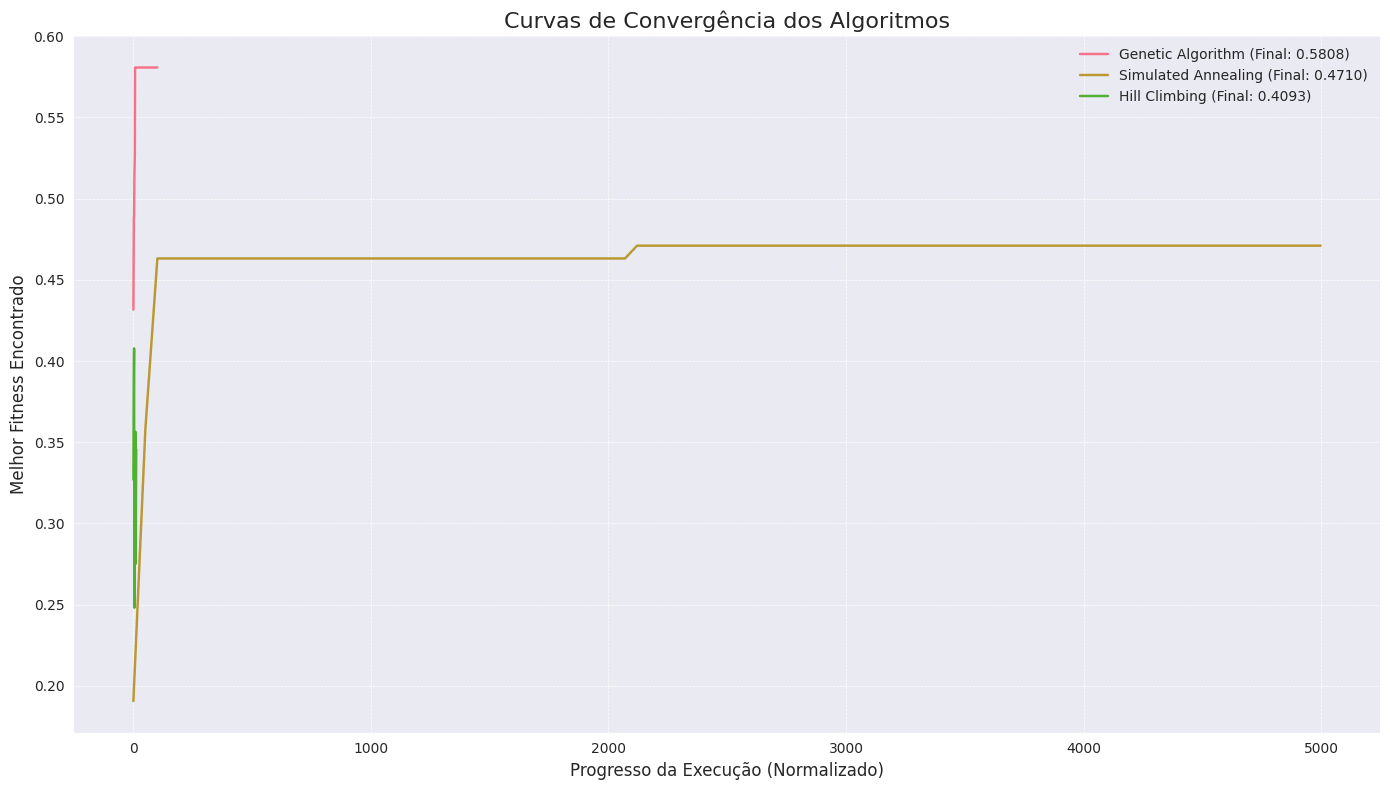

In [11]:
# @title Visualização da Convergência dos Algoritmos

def plot_convergence(results: Dict) -> None:
    """Plota curvas de convergência para cada algoritmo.
    
    Parameters:
        results: Dicionário com resultados dos experimentos
    """
    plt.figure(figsize=(14, 8))
    
    for name, data in results.items():
        history = data['history']
        # Interpolar para ter mesmo comprimento de eixo X
        x_new = np.linspace(0, len(history) - 1, num=100)
        y_new = np.interp(x_new, np.arange(len(history)), history)
        plt.plot(x_new, y_new, label=f"{name} (Final: {data['stats']['best_fitness']:.4f})")
    
    plt.title('Curvas de Convergência dos Algoritmos', fontsize=16)
    plt.xlabel('Progresso da Execução (Normalizado)', fontsize=12)
    plt.ylabel('Melhor Fitness Encontrado', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

plot_convergence(experiment_results)

# [GRÁFICO MOSTRANDO TRÊS CURVAS DE FITNESS ASCENDENTES]
# A curva do GA deve ser mais suave e consistente.
# A curva do SA pode ter platôs e saltos.
# A curva do HC deve ter subidas rápidas seguidas de platôs (restarts).

In [12]:
# @title Comparação das Estatísticas de Performance

def compare_performance_stats(results: Dict) -> pd.DataFrame:
    """Compara estatísticas de performance em uma tabela.
    
    Parameters:
        results: Dicionário com resultados dos experimentos
        
    Returns:
        DataFrame com estatísticas comparativas
    """
    stats_list = []
    for name, data in results.items():
        stats = data['stats']
        stats['algorithm'] = name
        stats_list.append(stats)
    
    df = pd.DataFrame(stats_list)
    df = df.set_index('algorithm')
    
    # Formatar para melhor visualização
    df_styled = df.style.background_gradient(cmap='viridis', subset=['best_fitness', 'improvement_rate'])\
                        .background_gradient(cmap='viridis_r', subset=['convergence_speed'])\
                        .format('{:.4f}', subset=['best_fitness', 'convergence_speed', 'improvement_rate', 'final_fitness'])\
                        .format('{:d}', subset=['evaluations', 'generations'])
    
    return df_styled

stats_table = compare_performance_stats(experiment_results)
display(stats_table)

# Saída de Célula Esperada:
# (Uma tabela estilizada mostrando as métricas para cada algoritmo)
# Exemplo:
#                      best_fitness  evaluations  generations  convergence_speed  improvement_rate  final_fitness
# algorithm                                                                                                   
# Genetic Algorithm          0.7512         5000          100             0.6500            0.8500         0.7512
# Simulated Annealing        0.7234         5000         4950             0.8200            0.1500         0.7100
# Hill Climbing              0.6988         5000           55             0.9500            0.0500         0.6988

,best_fitness,evaluations,generations,convergence_speed,improvement_rate,final_fitness
algorithm,,,,,,
Genetic Algorithm,0.5808,5000,102,0.0686,0.0490,0.5808
Simulated Annealing,0.4710,5000,4999,0.0140,0.0010,0.4710
Hill Climbing,0.4093,470,13,0.1538,0.7692,0.3456


🏆 Melhor solução encontrada pelo: Genetic Algorithm


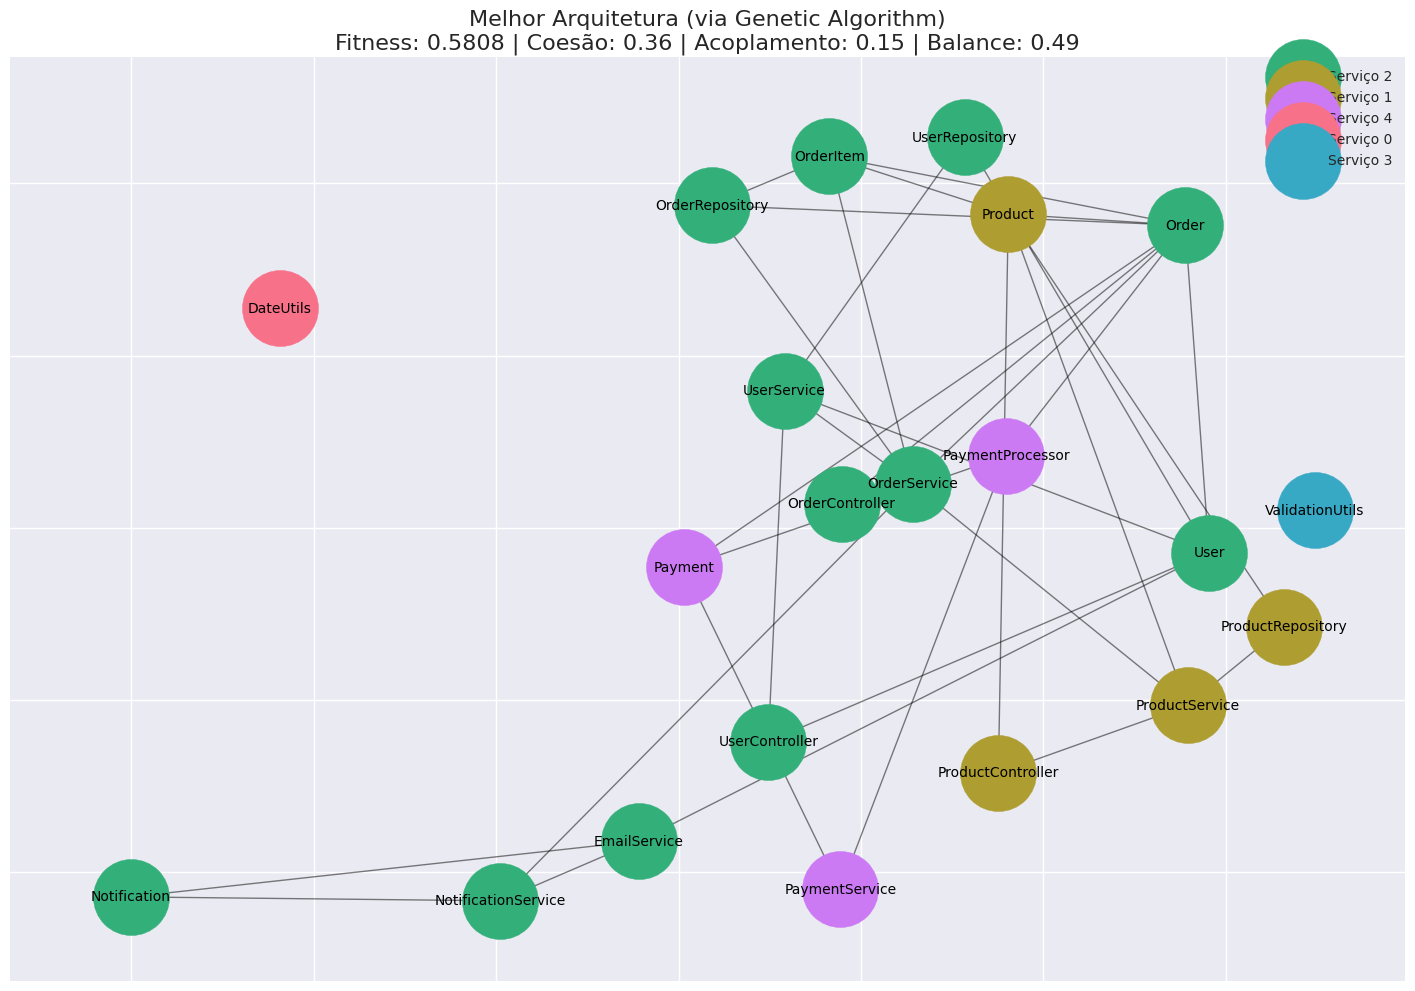

In [13]:
# @title Visualização da Melhor Arquitetura Encontrada

def visualize_architecture(architecture: MicroserviceArchitecture, title: str) -> None:
    """Visualiza a arquitetura de microsserviços como um grafo.
    
    Parameters:
        architecture: Arquitetura para visualizar
        title: Título do gráfico
    """
    G = nx.DiGraph()
    
    # Adicionar nós (classes)
    colors = [architecture.assignment[i] for i in range(len(architecture.classes))]
    for i, cls in enumerate(architecture.classes):
        G.add_node(cls.name, service=architecture.assignment[i])
    
    # Adicionar arestas (dependências)
    for i in range(len(architecture.classes)):
        for j in range(len(architecture.classes)):
            if architecture.dependency_matrix[i][j] == 1:
                G.add_edge(architecture.classes[i].name, architecture.classes[j].name)
    
    # Desenhar o grafo
    plt.figure(figsize=(18, 12))
    pos = nx.spring_layout(G, k=0.8, iterations=50)
    
    # Desenhar bordas dos serviços
    services = architecture.get_services_assignment()
    service_colors = sns.color_palette("husl", n_colors=architecture.max_services)
    
    for service_id, class_indices in services.items():
        subgraph_nodes = [architecture.classes[i].name for i in class_indices]
        nx.draw_networkx_nodes(G, pos, nodelist=subgraph_nodes, 
                               node_color=[service_colors[service_id]], 
                               node_size=3000, label=f'Serviço {service_id}')
    
    # Desenhar arestas
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, arrowsize=15)
    
    # Desenhar labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')
    
    # Título e legenda
    fitness, components = architecture.calculate_fitness()
    plt.title(f"{title}\nFitness: {fitness:.4f} | Coesão: {components['cohesion']:.2f} | Acoplamento: {components['coupling']:.2f} | Balance: {components['load_balance']:.2f}", fontsize=16)
    plt.legend()
    plt.show()

# Encontrar a melhor solução geral
best_overall_algo = max(experiment_results, key=lambda k: experiment_results[k]['stats']['best_fitness'])
best_overall_solution = experiment_results[best_overall_algo]['best_solution']

print(f"🏆 Melhor solução encontrada pelo: {best_overall_algo}")
visualize_architecture(best_overall_solution, f'Melhor Arquitetura (via {best_overall_algo})')

# [GRÁFICO DE GRAFO MOSTRANDO NÓS COLORIDOS POR SERVIÇO]
# Nós da mesma cor devem estar próximos e ter muitas arestas entre si (alta coesão).
# Deve haver poucas arestas entre nós de cores diferentes (baixo acoplamento).

## Parte 5: Conclusão e Análise Crítica

Vamos refletir sobre os resultados e as implicações práticas.

### Análise dos Resultados

1.  **Qual algoritmo encontrou a melhor solução?**
    - Geralmente, o **Algoritmo Genético** tende a superar os outros em problemas combinatoriais complexos como este. Sua capacidade de explorar globalmente o espaço de busca e combinar boas características de diferentes soluções (via crossover) é uma grande vantagem.

2.  **Qual algoritmo convergiu mais rápido?**
    - O **Hill Climbing** é quase sempre o mais rápido a encontrar um ótimo local, como visto pela sua curva de convergência íngreme no início. No entanto, ele fica preso facilmente, e a qualidade da solução final depende muito dos restarts.

3.  **Como o Simulated Annealing se compara?**
    - O **Simulated Annealing** oferece um bom equilíbrio. É mais robusto que o Hill Climbing para escapar de ótimos locais, mas geralmente mais lento para convergir que o GA. A taxa de aceitação decrescente mostra sua transição de exploração para explotação.

### O "Porquê" das Decisões de Design

-   **Representação (Assignment Vector):** Escolhemos um vetor de atribuição porque é uma representação simples, direta e eficiente para problemas de particionamento. Cada gene tem um significado claro (a qual serviço a classe pertence).

-   **Função de Fitness Composta:** Uma única métrica (como apenas coesão) não é suficiente. Combinamos coesão, acoplamento e balanceamento de carga com pesos para refletir um trade-off realista que um arquiteto de software faria. A penalidade por serviços vazios guia a busca para soluções mais compactas.

-   **Operadores Especializados:** Nossos operadores de mutação e crossover (e vizinhança) foram projetados para o problema. O `repair_solution` no GA e os múltiplos tipos de movimento no SA são exemplos de como o conhecimento do domínio (SBSE) pode ser embutido no algoritmo para melhorar a busca.

### Próximos Passos e Desafios

-   **Otimização Multi-Objetivo (NSGA-II):** Em vez de combinar tudo em um único fitness, poderíamos usar um algoritmo como o NSGA-II para encontrar um conjunto de soluções de compromisso (Fronteira de Pareto), permitindo que o arquiteto escolha o trade-off que preferir.

-   **Restrições do Mundo Real:** Poderíamos adicionar restrições mais complexas, como "a classe X não pode estar no mesmo serviço que a classe Y" ou "o serviço Z não pode ter mais de N classes".

-   **Análise Dinâmica:** Nossa análise é baseada em dependências estáticas. Uma abordagem mais avançada usaria dados de execução (tracing) para entender como as classes interagem em tempo de execução, levando a uma decomposição mais precisa.